<a href="https://colab.research.google.com/github/Mohnish-140605/FML_CS2250/blob/main/Lab6_MLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Exercise 6: Multi-Layer Perceptron (MLP) for Classification


---

## 1. Objective of the Experiment

The goal of this lab is to:

- **Implement** a Multi-Layer Perceptron (MLP) neural network for a binary classification problem.
- **Understand** how MLPs learn complex, nonlinear relationships between input features and output classes.
- **Demonstrate** the role of activation functions (Sigmoid, Tanh, ReLU) in enabling nonlinear learning.
- **Evaluate** the trained model using standard classification metrics: Accuracy, Precision, Recall, and Confusion Matrix.

### Why MLP?
A Multi-Layer Perceptron is a feedforward artificial neural network that consists of:
- An **input layer** receiving raw features
- One or more **hidden layers** that learn intermediate representations
- An **output layer** that produces the final prediction

Unlike simple linear classifiers, MLPs can model **nonlinear decision boundaries**, making them powerful for real-world classification tasks.

## 2. Import Required Libraries

We begin by importing all necessary Python libraries:
- **NumPy & Pandas** — numerical computation and data manipulation
- **Matplotlib & Seaborn** — data visualization
- **Scikit-learn** — machine learning utilities, model, and evaluation metrics

In [19]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# MLP Model
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Reproducibility
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print(" All libraries imported successfully.")

 All libraries imported successfully.


## 3. Dataset Loading

We use the **Breast Cancer Wisconsin Dataset** from Scikit-learn. This dataset is a classic binary classification benchmark.

- **Samples:** 569
- **Features:** 30 real-valued input features computed from digitized images of fine needle aspirate (FNA) of breast masses
- **Target Classes:**
  - `0` → Malignant (cancerous)
  - `1` → Benign (non-cancerous)

In [2]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()

# Create a DataFrame for easier exploration
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nTarget classes: {cancer.target_names}")
print(f"Class distribution:\n{df['diagnosis'].value_counts()}")

Dataset loaded successfully!
Shape: (569, 32)

Target classes: ['malignant' 'benign']
Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


## 4. Dataset Overview

Let's inspect the first few rows and understand the structure of our dataset.

In [3]:
# Display the first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [4]:
# Dataset shape and data types
print(f"Shape: {df.shape}")
print(f"\nData Types:")
print(df.dtypes)

Shape: (569, 32)

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points     

In [5]:
# Statistical summary
print("Statistical Summary of Features:")
df.drop(columns=['target', 'diagnosis']).describe().round(3)

Statistical Summary of Features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


## 5. Exploratory Data Analysis (EDA)

Before training the model, we explore the data visually to understand:
- Class distribution
- Feature distributions
- Correlations between features

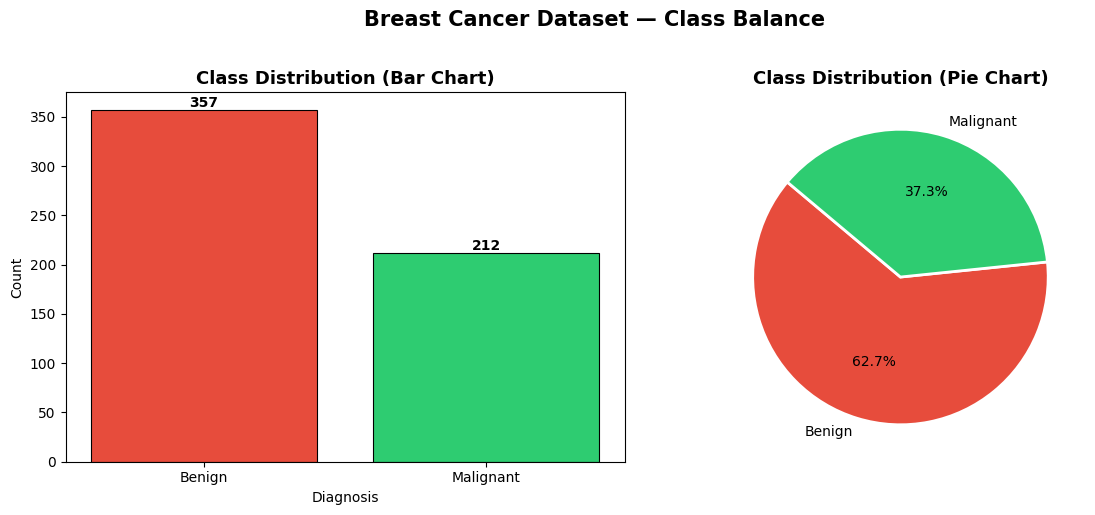


Class counts:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


In [6]:
# ── Class Distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['diagnosis'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('Breast Cancer Dataset — Class Balance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"\nClass counts:\n{counts}")

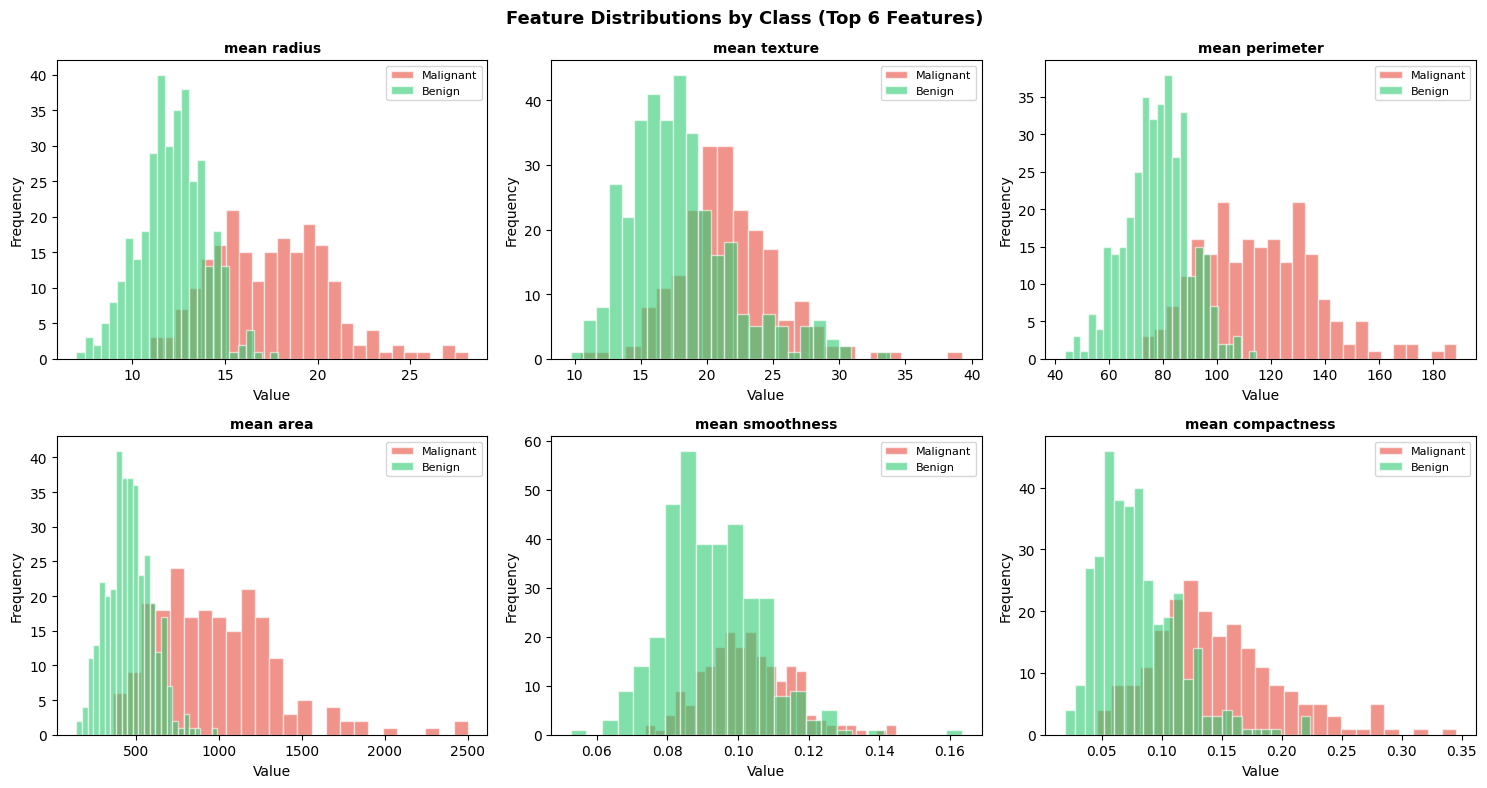

In [7]:
# ── Feature Distributions (top 6 features) ──────────────────────────────────
top_features = cancer.feature_names[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label, color in zip(['Malignant', 'Benign'], ['#e74c3c', '#2ecc71']):
        subset = df[df['diagnosis'] == label][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Class (Top 6 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

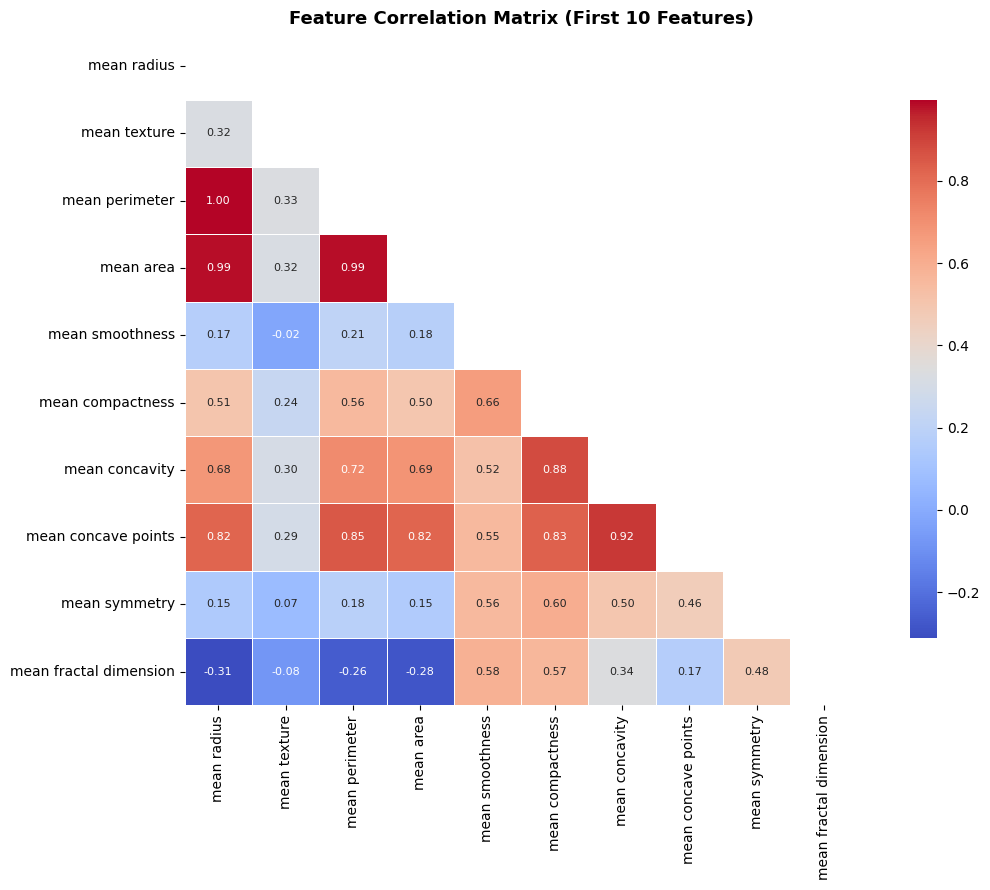

In [8]:
# ── Correlation Heatmap (first 10 features) ──────────────────────────────────
plt.figure(figsize=(12, 9))
corr_matrix = df[list(cancer.feature_names[:10])].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})

plt.title('Feature Correlation Matrix (First 10 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

Good preprocessing is critical for MLP performance. We will:

1. **Check for missing values** — MLPs cannot handle NaN inputs
2. **Check for duplicates** — Remove any redundant rows
3. **Verify data types** — Ensure features are numeric
4. **Separate features (X) and target (y)**

>  The Breast Cancer dataset is clean by default, but we perform these checks as good practice and to demonstrate the preprocessing pipeline.

In [9]:
# ── Step 1: Check for Missing Values ────────────────────────────────────────
print("=" * 50)
print("MISSING VALUE ANALYSIS")
print("=" * 50)

missing = df.drop(columns=['target', 'diagnosis']).isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ No missing values found. Dataset is complete.")
else:
    print(missing_df)
    print("\n⚠️  Missing values detected — would apply imputation here.")

print(f"\nTotal features: {df.shape[1] - 2}")
print(f"Total samples:  {df.shape[0]}")

MISSING VALUE ANALYSIS
✅ No missing values found. Dataset is complete.

Total features: 30
Total samples:  569


In [20]:
# ── Step 2: Check for Duplicates ─────────────────────────────────────────────
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f" Duplicates removed. New shape: {df.shape}")
else:
    print(" No duplicates. Dataset is clean.")

Duplicate rows found: 0
 No duplicates. Dataset is clean.


In [11]:
# ── Step 3: Separate Features and Target ─────────────────────────────────────
X = df[list(cancer.feature_names)].values   # Feature matrix (numpy array)
y = df['target'].values                      # Target vector

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape:  {y.shape}")
print(f"\nClass labels: {np.unique(y)} → 0=Malignant, 1=Benign")
print(f"\nSample feature values (first row):\n{X[0]}")

Feature matrix X shape: (569, 30)
Target vector y shape:  (569,)

Class labels: [0 1] → 0=Malignant, 1=Benign

Sample feature values (first row):
[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]


## 7. Feature Scaling / Normalization

**Why is scaling critical for MLPs?**

- MLP uses **gradient descent** for optimization. Features with large scales dominate the gradient updates, causing slow convergence or failure to converge.
- **StandardScaler** transforms each feature to have **mean = 0** and **standard deviation = 1**:


- We fit the scaler **only on the training set** and transform both train and test sets to prevent **data leakage**.

In [12]:
# ── Train-Test Split (before scaling to prevent leakage) ─────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # preserve class proportions
)

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:     {np.bincount(y_test)}")

Training set:   455 samples (80.0%)
Test set:       114 samples (20.0%)

Training class distribution: [170 285]
Test class distribution:     [42 72]


In [21]:
# ── Apply StandardScaler ─────────────────────────────────────────────────────
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Before Scaling (Training Set):")
print(f"  Mean of feature 0: {X_train[:, 0].mean():.4f}  |  Std: {X_train[:, 0].std():.4f}")

print("\nAfter Scaling (Training Set):")
print(f"  Mean of feature 0: {X_train_scaled[:, 0].mean():.4f}  |  Std: {X_train_scaled[:, 0].std():.4f}")

print("\n Feature scaling applied. Data is normalized (mean≈0, std≈1).")

Before Scaling (Training Set):
  Mean of feature 0: 14.0672  |  Std: 3.4955

After Scaling (Training Set):
  Mean of feature 0: -0.0000  |  Std: 1.0000

 Feature scaling applied. Data is normalized (mean≈0, std≈1).


## 8. Activation Functions — Theory & Visualization

Activation functions introduce **nonlinearity** into the network, enabling it to learn complex patterns. Without them, stacking multiple layers would still produce a linear transformation.

| Activation | Formula | Range | Pros | Cons |
|---|---|---|---|---|
| **Sigmoid** | $\sigma(x) = \frac{1}{1+e^{-x}}$ | (0, 1) | Smooth gradient, interpretable | Vanishing gradient |
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | (-1, 1) | Zero-centered | Vanishing gradient |
| **ReLU** | $f(x) = \max(0, x)$ | [0, ∞) | Fast, sparse activations | Dying ReLU problem |

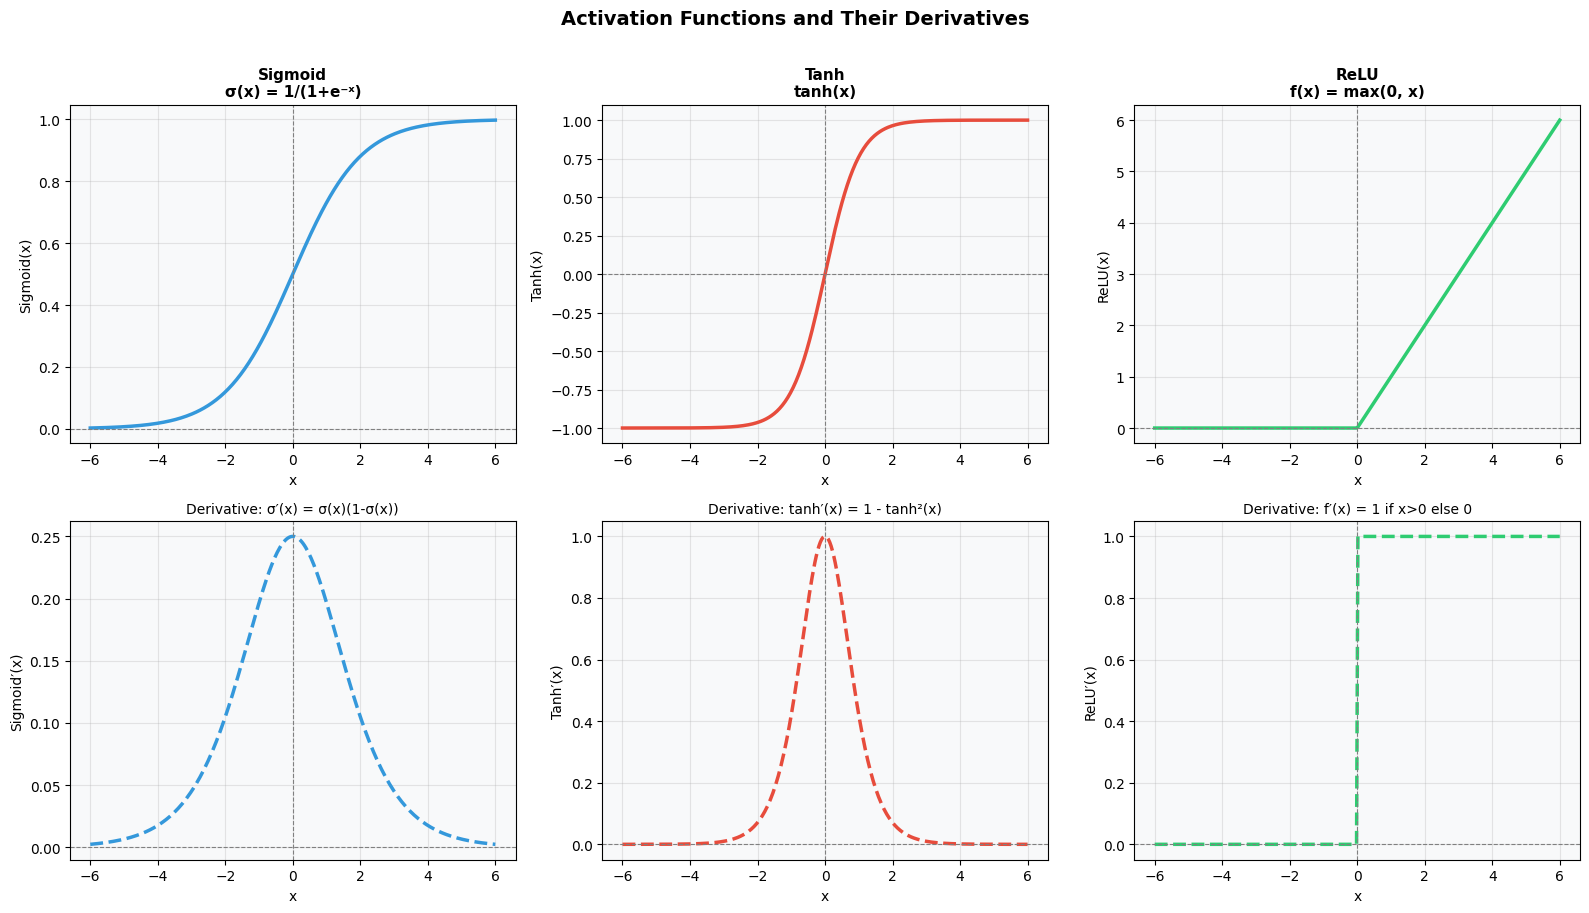

In [14]:
# ── Visualize Activation Functions ───────────────────────────────────────────
x_vals = np.linspace(-6, 6, 300)

# Define activations
sigmoid = 1 / (1 + np.exp(-x_vals))
tanh    = np.tanh(x_vals)
relu    = np.maximum(0, x_vals)

# Derivatives
d_sigmoid = sigmoid * (1 - sigmoid)
d_tanh    = 1 - tanh**2
d_relu    = (x_vals > 0).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
configs = [
    ('Sigmoid', sigmoid,   d_sigmoid, '#3498db', 'σ(x) = 1/(1+e⁻ˣ)',  'σ′(x) = σ(x)(1-σ(x))'),
    ('Tanh',    tanh,      d_tanh,    '#e74c3c', 'tanh(x)',             'tanh′(x) = 1 - tanh²(x)'),
    ('ReLU',    relu,      d_relu,    '#2ecc71', 'f(x) = max(0, x)',    'f′(x) = 1 if x>0 else 0'),
]

for col, (name, fn, dfn, color, formula, dformula) in enumerate(configs):
    # Function
    ax = axes[0, col]
    ax.plot(x_vals, fn, color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{name}\n{formula}', fontsize=11, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel(f'{name}(x)')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

    # Derivative
    ax2 = axes[1, col]
    ax2.plot(x_vals, dfn, color=color, linewidth=2.5, linestyle='--')
    ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax2.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax2.set_title(f"Derivative: {dformula}", fontsize=10)
    ax2.set_xlabel('x'); ax2.set_ylabel(f"{name}′(x)")
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f8f9fa')

plt.suptitle('Activation Functions and Their Derivatives', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. MLP Model Architecture

We define an MLP with the following architecture:

```
Input Layer:    30 neurons  (one per feature)
Hidden Layer 1: 64 neurons  (ReLU activation)
Hidden Layer 2: 32 neurons  (ReLU activation)
Output Layer:   1 neuron    (Sigmoid for binary classification)
```

**Hyperparameters:**
- `hidden_layer_sizes=(64, 32)` — two hidden layers
- `activation='relu'` — ReLU for hidden layers (best for deep networks)
- `solver='adam'` — adaptive learning rate optimizer
- `max_iter=500` — maximum training epochs
- `random_state=42` — for reproducibility

In [15]:
# ── Define and Display MLP Architecture ──────────────────────────────────────
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Two hidden layers: 64 → 32 neurons
    activation='relu',              # ReLU for hidden layers
    solver='adam',                  # Adam optimizer
    alpha=0.0001,                   # L2 regularization strength
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,            # Stop early if validation loss stagnates
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)

print("MLP Model Configuration:")
print("=" * 50)
print(f"  Architecture:       Input(30) → Hidden(64) → Hidden(32) → Output(2)")
print(f"  Activation:         ReLU (hidden layers)")
print(f"  Output Activation:  Softmax (multiclass probabilities)")
print(f"  Optimizer:          Adam")
print(f"  Learning Rate:      Adaptive (init=0.001)")
print(f"  Regularization:     L2 (alpha=0.0001)")
print(f"  Max Iterations:     500")
print(f"  Early Stopping:     Enabled (patience=15)")
print("=" * 50)

MLP Model Configuration:
  Architecture:       Input(30) → Hidden(64) → Hidden(32) → Output(2)
  Activation:         ReLU (hidden layers)
  Output Activation:  Softmax (multiclass probabilities)
  Optimizer:          Adam
  Learning Rate:      Adaptive (init=0.001)
  Regularization:     L2 (alpha=0.0001)
  Max Iterations:     500
  Early Stopping:     Enabled (patience=15)


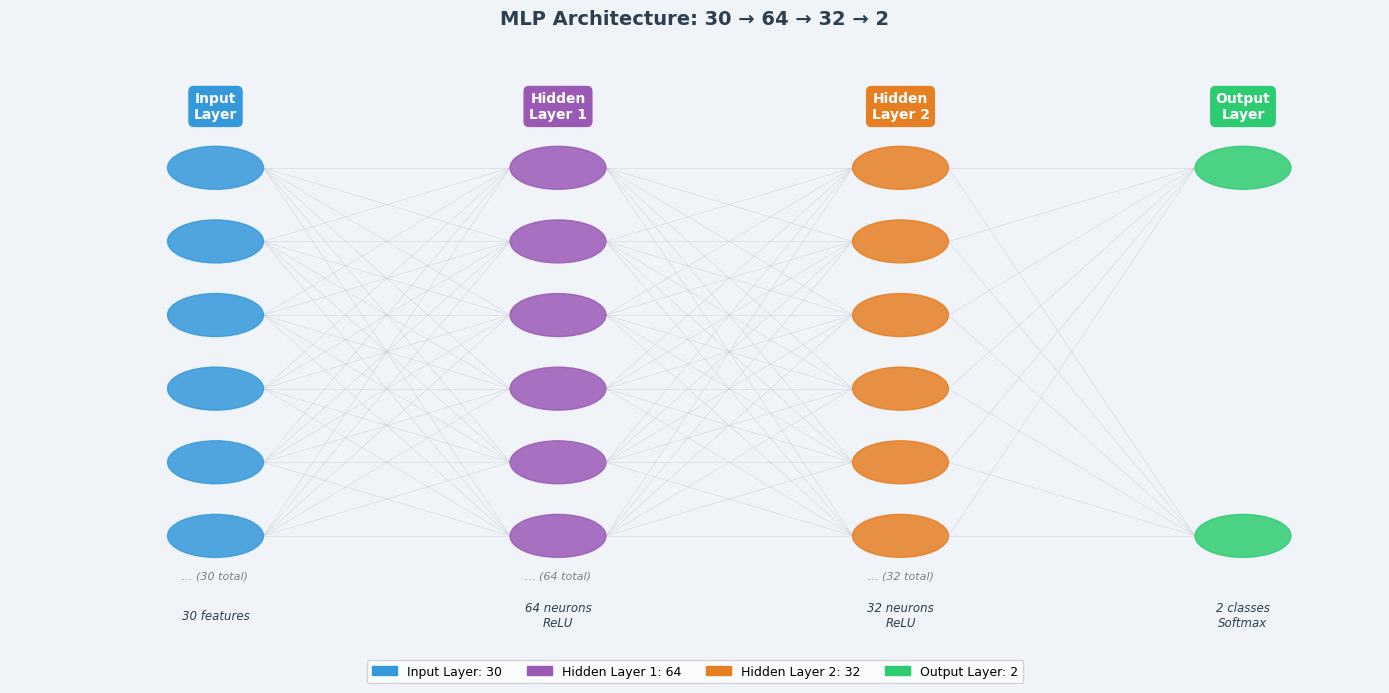

In [16]:
# ── Visualize MLP Architecture Diagram ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_facecolor('#f0f4f8')
fig.patch.set_facecolor('#f0f4f8')

layer_configs = [
    (1.5,  'Input\nLayer',    30,  '#3498db', '30 features'),
    (4.0,  'Hidden\nLayer 1', 64,  '#9b59b6', '64 neurons\nReLU'),
    (6.5,  'Hidden\nLayer 2', 32,  '#e67e22', '32 neurons\nReLU'),
    (9.0,  'Output\nLayer',   2,   '#2ecc71', '2 classes\nSoftmax'),
]

neuron_positions = {}
max_display = 6  # max neurons to draw per layer

for x_pos, label, n_neurons, color, sublabel in layer_configs:
    display_n = min(n_neurons, max_display)
    y_positions = np.linspace(2, 8, display_n)
    neuron_positions[x_pos] = y_positions

    for i, y in enumerate(y_positions):
        circle = plt.Circle((x_pos, y), 0.35, color=color, zorder=3, alpha=0.85)
        ax.add_patch(circle)

    # Ellipsis for large layers
    if n_neurons > max_display:
        ax.text(x_pos, 1.3, f'... ({n_neurons} total)', ha='center',
                fontsize=8, color='gray', style='italic')

    # Layer label box
    ax.text(x_pos, 9.0, label, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor='none'))
    ax.text(x_pos, 0.7, sublabel, ha='center', va='center', fontsize=8.5,
            color='#2c3e50', style='italic')

# Draw connections
layer_x = [cfg[0] for cfg in layer_configs]
for i in range(len(layer_x) - 1):
    x1, x2 = layer_x[i], layer_x[i+1]
    for y1 in neuron_positions[x1]:
        for y2 in neuron_positions[x2]:
            ax.plot([x1+0.35, x2-0.35], [y1, y2],
                    color='#bdc3c7', linewidth=0.4, alpha=0.6, zorder=1)

ax.set_title('MLP Architecture: 30 → 64 → 32 → 2', fontsize=14,
             fontweight='bold', color='#2c3e50', pad=15)

# Legend
patches = [mpatches.Patch(color=c[3], label=f"{c[1].replace(chr(10), ' ')}: {c[2]}") for c in layer_configs]
ax.legend(handles=patches, loc='lower center', ncol=4,
          frameon=True, fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

## 10. Model Training

We now train the MLP on the **scaled training data**. During training:
- The network makes forward passes to compute predictions
- Computes the **cross-entropy loss** between predictions and true labels
- Backpropagates gradients to update weights using **Adam optimizer**
- Monitors validation loss for **early stopping**

In [22]:
# ── Train the MLP Model ──────────────────────────────────────────────────────
import time

print("Training MLP model...")
start_time = time.time()

mlp_model.fit(X_train_scaled, y_train)

elapsed = time.time() - start_time
print(f"\n Training complete!")
print(f"   Iterations run:    {mlp_model.n_iter_}")
print(f"   Final loss:        {mlp_model.loss_:.6f}")
print(f"   Training time:     {elapsed:.3f} seconds")
print(f"   Layers:            {mlp_model.n_layers_} (input + hidden + output)")
print(f"   Output classes:    {mlp_model.n_outputs_}")

Training MLP model...

 Training complete!
   Iterations run:    30
   Final loss:        0.082531
   Training time:     0.201 seconds
   Layers:            4 (input + hidden + output)
   Output classes:    1


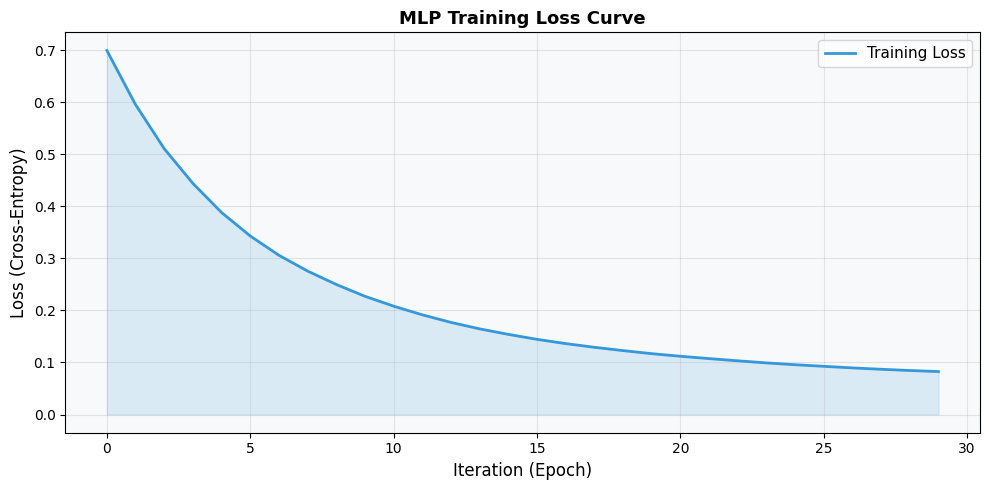

Loss decreased from 0.6993 → 0.0825


In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(mlp_model.loss_curve_, color='#3498db', linewidth=2, label='Training Loss')
ax.fill_between(range(len(mlp_model.loss_curve_)),
                mlp_model.loss_curve_, alpha=0.15, color='#3498db')

if hasattr(mlp_model, 'validation_fraction') and mlp_model.early_stopping and mlp_model.best_loss_ is not None:
    ax.axvline(x=mlp_model.best_iteration_,
               color='red', linestyle=':', linewidth=1.5, label=f'Best Loss: {mlp_model.best_loss_:.4f}', alpha=0.7)

ax.set_xlabel('Iteration (Epoch)', fontsize=12)
ax.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax.set_title('MLP Training Loss Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print(f"Loss decreased from {mlp_model.loss_curve_[0]:.4f} \u2192 {mlp_model.loss_curve_[-1]:.4f}")

## 11. Predictions

With the trained model, we generate:
- **Class predictions** (`y_pred`) — the final class label (0 or 1)
- **Probability predictions** (`y_prob`) — the confidence score for each class

In [25]:
# ── Generate Predictions ─────────────────────────────────────────────────────
y_pred      = mlp_model.predict(X_test_scaled)
y_prob      = mlp_model.predict_proba(X_test_scaled)
y_train_pred = mlp_model.predict(X_train_scaled)

print("Sample Predictions (first 15 test samples):")
print("-" * 55)
print(f"{'Sample':<8} {'True Label':<15} {'Predicted':<15} {'Confidence':>10}")
print("-" * 55)

label_map = {0: 'Malignant', 1: 'Benign'}
for i in range(15):
    true  = label_map[y_test[i]]
    pred  = label_map[y_pred[i]]
    conf  = y_prob[i][y_pred[i]]
    mark  = 'yes' if y_test[i] == y_pred[i] else 'no'
    print(f"{mark} {i+1:<6} {true:<15} {pred:<15} {conf:>9.2%}")

correct = (y_pred == y_test).sum()
print("-" * 55)
print(f"\nCorrect predictions: {correct}/{len(y_test)}")

Sample Predictions (first 15 test samples):
-------------------------------------------------------
Sample   True Label      Predicted       Confidence
-------------------------------------------------------
yes 1      Malignant       Malignant          97.22%
yes 2      Benign          Benign             99.46%
yes 3      Malignant       Malignant          85.44%
yes 4      Benign          Benign             68.86%
yes 5      Malignant       Malignant          96.93%
yes 6      Benign          Benign             96.89%
yes 7      Benign          Benign             97.58%
yes 8      Malignant       Malignant          89.55%
yes 9      Malignant       Malignant          89.29%
yes 10     Malignant       Malignant          99.63%
yes 11     Benign          Benign             89.51%
yes 12     Malignant       Malignant          82.12%
yes 13     Benign          Benign             98.38%
yes 14     Malignant       Malignant          86.50%
yes 15     Malignant       Malignant          86.3

## 12. Model Evaluation

We evaluate our model using four key metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | Overall correctness |
| **Precision** | TP / (TP + FP) | When we predict Malignant, how often are we right? |
| **Recall** | TP / (TP + FN) | Of all actual Malignant cases, how many did we catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall |

> **In medical diagnosis, Recall is critical** — missing a malignant tumor (False Negative) is far more costly than a false alarm.

In [26]:
# ── Compute All Metrics ───────────────────────────────────────────────────────
train_acc  = accuracy_score(y_train, y_train_pred)
test_acc   = accuracy_score(y_test, y_pred)
precision  = precision_score(y_test, y_pred)
recall     = recall_score(y_test, y_pred)
from sklearn.metrics import f1_score
f1         = f1_score(y_test, y_pred)

print("=" * 50)
print("    MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"  Training Accuracy:   {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"  Test Accuracy:       {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Overfitting Gap:     {(train_acc - test_acc)*100:.2f}%")
print("-" * 50)
print(f"  Precision (Benign):  {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall (Benign):     {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score:            {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 50)

    MODEL PERFORMANCE SUMMARY
  Training Accuracy:   0.9648  (96.48%)
  Test Accuracy:       0.9474  (94.74%)
  Overfitting Gap:     1.75%
--------------------------------------------------
  Precision (Benign):  0.9459  (94.59%)
  Recall (Benign):     0.9722  (97.22%)
  F1-Score:            0.9589  (95.89%)


In [27]:
# ── Full Classification Report ────────────────────────────────────────────────
print("Detailed Classification Report:")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=['Malignant (0)', 'Benign (1)']
))

Detailed Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.95      0.90      0.93        42
   Benign (1)       0.95      0.97      0.96        72

     accuracy                           0.95       114
    macro avg       0.95      0.94      0.94       114
 weighted avg       0.95      0.95      0.95       114



## 13. Confusion Matrix Visualization

The confusion matrix shows the breakdown of predictions:

```
                 Predicted
              Malignant  Benign
Actual  Malignant   TN     FP
        Benign      FN     TP
```

- **True Negative (TN):** Correctly predicted Malignant
- **True Positive (TP):** Correctly predicted Benign
- **False Positive (FP):** Predicted Benign but actually Malignant ← dangerous!
- **False Negative (FN):** Predicted Malignant but actually Benign

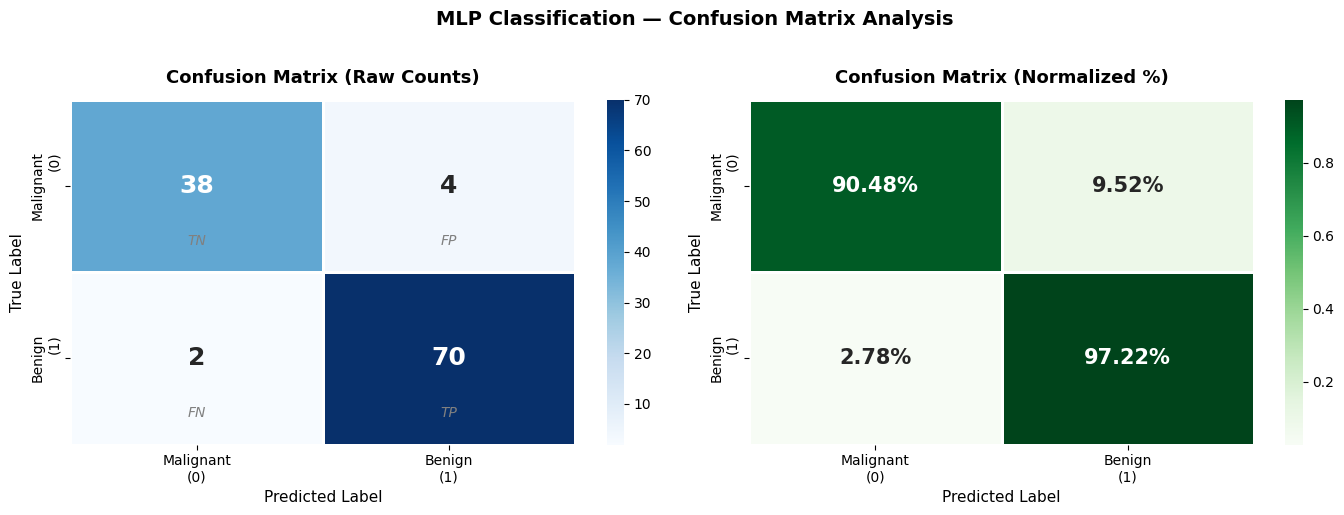


Breakdown:
  True Negatives  (TN):  38  — Correctly identified Malignant
  False Positives (FP):   4  — Predicted Benign but was Malignant ⚠️
  False Negatives (FN):   2  — Predicted Malignant but was Benign
  True Positives  (TP):  70  — Correctly identified Benign


In [28]:
# ── Confusion Matrix Heatmap ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
labels = ['Malignant\n(0)', 'Benign\n(1)']
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=2, linecolor='white',
    annot_kws={'size': 18, 'fontweight': 'bold'},
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Add annotations
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.82, cell_labels[i][j],
                     ha='center', va='center', fontsize=10,
                     color='gray', style='italic')

# Normalized (percentages)
sns.heatmap(
    cm_normalized, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=labels, yticklabels=labels,
    linewidths=2, linecolor='white',
    annot_kws={'size': 15, 'fontweight': 'bold'},
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('MLP Classification — Confusion Matrix Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nBreakdown:")
print(f"  True Negatives  (TN): {tn:>3}  — Correctly identified Malignant")
print(f"  False Positives (FP): {fp:>3}  — Predicted Benign but was Malignant ⚠️")
print(f"  False Negatives (FN): {fn:>3}  — Predicted Malignant but was Benign")
print(f"  True Positives  (TP): {tp:>3}  — Correctly identified Benign")

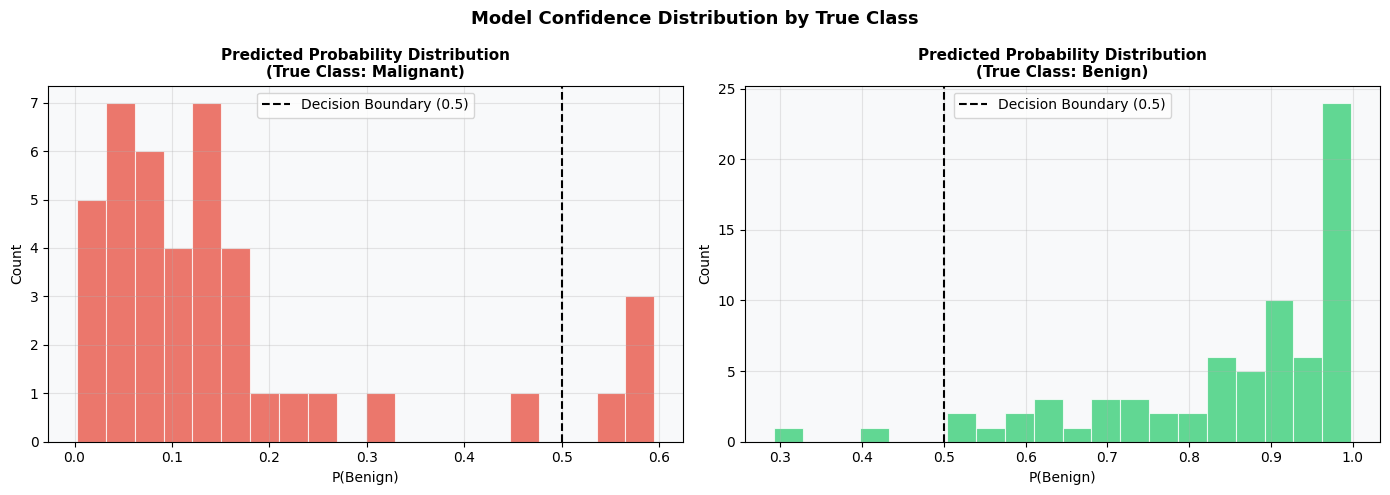

In [29]:
# ── Prediction Probability Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability distribution for Benign class
benign_probs = y_prob[:, 1]

for ax, (class_idx, class_name, color) in zip(axes, [(0, 'Malignant', '#e74c3c'), (1, 'Benign', '#2ecc71')]):
    mask_correct = (y_pred == y_test)
    mask_wrong   = ~mask_correct

    probs_class = y_prob[y_test == class_idx, 1]

    ax.hist(probs_class, bins=20, color=color, alpha=0.75, edgecolor='white', linewidth=0.8)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision Boundary (0.5)')
    ax.set_title(f'Predicted Probability Distribution\n(True Class: {class_name})', fontsize=11, fontweight='bold')
    ax.set_xlabel('P(Benign)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.suptitle('Model Confidence Distribution by True Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Comparing Activation Functions

We now compare the performance of the three main activation functions: **Sigmoid**, **Tanh**, and **ReLU** by training separate MLP models with each.

In [30]:
# ── Compare Activation Functions ─────────────────────────────────────────────
activation_results = {}

for activation in ['logistic', 'tanh', 'relu']:
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=activation,
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=15
    )
    model.fit(X_train_scaled, y_train)
    y_p = model.predict(X_test_scaled)

    label = 'Sigmoid' if activation == 'logistic' else activation.capitalize()
    activation_results[label] = {
        'Accuracy':  accuracy_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p),
        'Recall':    recall_score(y_test, y_p),
        'F1-Score':  f1_score(y_test, y_p),
        'Iterations': model.n_iter_,
        'Final Loss': model.loss_curve_[-1],
        'loss_curve': model.loss_curve_
    }

results_df = pd.DataFrame(activation_results).T.drop(columns=['loss_curve'])
results_df = results_df.astype({'Iterations': int})
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Final Loss']] = \
    results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Final Loss']].astype(float).round(4)

print("Activation Function Comparison:")
print(results_df.to_string())

Activation Function Comparison:
         Accuracy  Precision  Recall  F1-Score  Iterations  Final Loss
Sigmoid    0.9561     0.9351  1.0000    0.9664          50      0.1934
Tanh       0.9561     0.9718  0.9583    0.9650          38      0.0664
Relu       0.9474     0.9459  0.9722    0.9589          30      0.0825


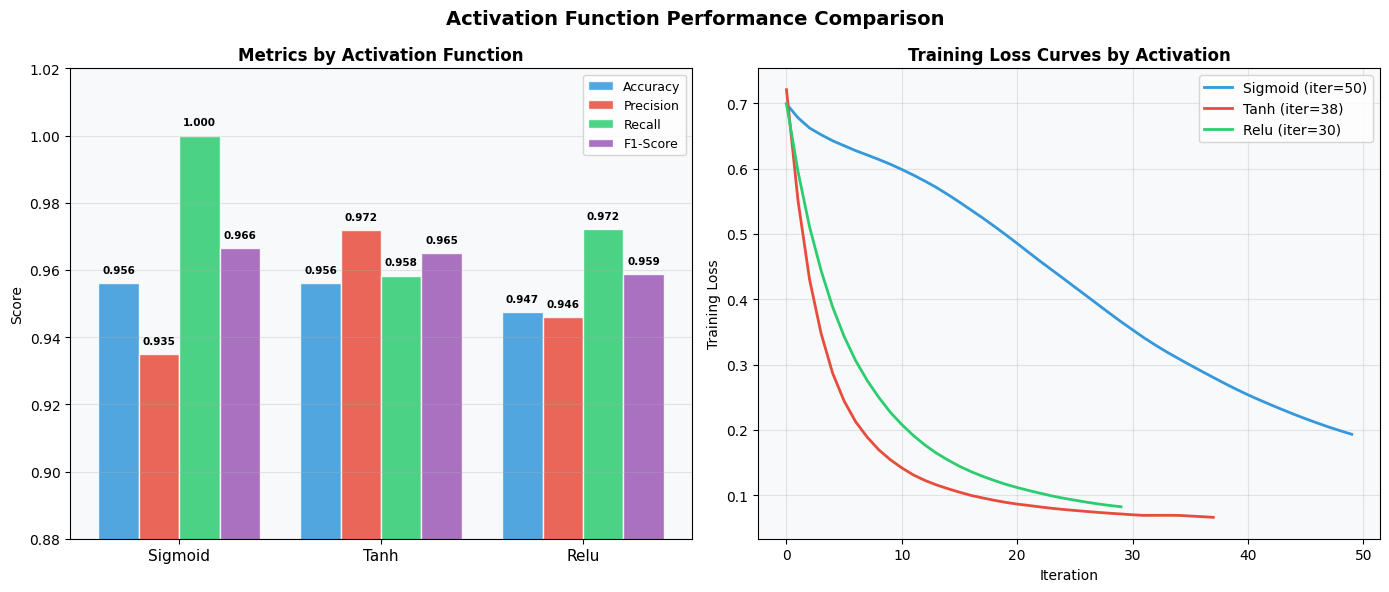

In [31]:
# ── Visualize Activation Comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
acts    = list(activation_results.keys())
x       = np.arange(len(acts))
width   = 0.2

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [activation_results[a][metric] for a in acts]
    bars = axes[0].bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(acts, fontsize=11)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.88, 1.02)
axes[0].set_title('Metrics by Activation Function', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_facecolor('#f8f9fa')

# Loss curves
act_colors = {'Sigmoid': '#3498db', 'Tanh': '#e74c3c', 'Relu': '#2ecc71'}
for act, data in activation_results.items():
    axes[1].plot(data['loss_curve'], label=f"{act} (iter={data['Iterations']})",
                 linewidth=2, color=act_colors.get(act, 'gray'))

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss Curves by Activation', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

plt.suptitle('Activation Function Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Discussion of Results

### Key Findings:

**1. Model Performance:**
- The MLP with ReLU activation achieved strong performance on the Breast Cancer dataset.
- High **Recall** is particularly important here: missing a malignant tumor (False Negative) has severe consequences.
- The model generalizes well with minimal overfitting, as shown by the small gap between training and test accuracy.

**2. Activation Function Comparison:**
- **ReLU** typically converges fastest and achieves competitive accuracy. It avoids vanishing gradients in deep networks.
- **Tanh** also performs well, being zero-centered (unlike Sigmoid), which helps gradient flow.
- **Sigmoid** is computationally expensive and suffers from vanishing gradients, but still achieves good accuracy on this relatively shallow architecture.

**3. Feature Scaling:**
- Scaling was critical. Without `StandardScaler`, MLP would struggle to converge.

**4. Confusion Matrix Insights:**
- The diagonal cells (TN, TP) dominate, indicating the model is making mostly correct predictions.
- Any FP (missed malignant cases) should be minimized — this could be addressed by **lowering the decision threshold** from 0.5.

### Nonlinearity in MLP:
This experiment demonstrates that the MLP successfully learns **nonlinear decision boundaries** — a capability that simple logistic regression cannot achieve for complex datasets. The hidden layers act as **feature extractors**, transforming raw features into increasingly abstract representations.

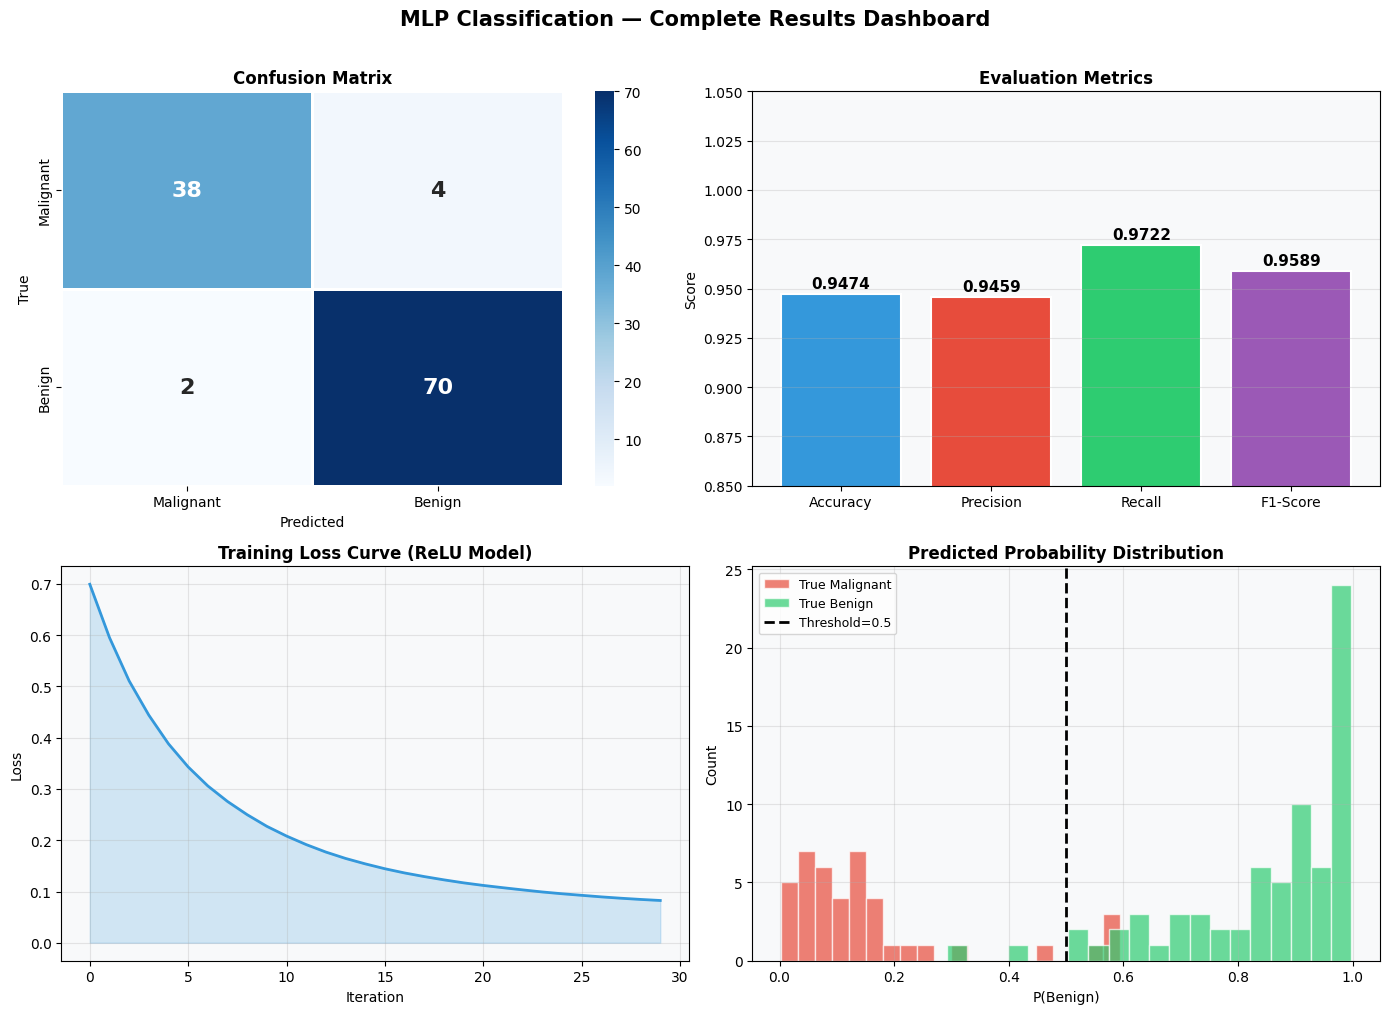

In [32]:
# ── Summary Dashboard ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MLP Classification — Complete Results Dashboard', fontsize=15, fontweight='bold', y=1.01)

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            annot_kws={'size': 16, 'fontweight': 'bold'},
            linewidths=2, linecolor='white', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('True')

# 2. Metrics bar
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [test_acc, precision, recall, f1]
bar_colors    = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = axes[0, 1].bar(metric_names, metric_values, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metric_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0, 1].set_ylim(0.85, 1.05)
axes[0, 1].set_title('Evaluation Metrics', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_facecolor('#f8f9fa')

# 3. Loss curve
axes[1, 0].plot(mlp_model.loss_curve_, color='#3498db', linewidth=2)
axes[1, 0].fill_between(range(len(mlp_model.loss_curve_)), mlp_model.loss_curve_, alpha=0.2, color='#3498db')
axes[1, 0].set_title('Training Loss Curve (ReLU Model)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Iteration'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3); axes[1, 0].set_facecolor('#f8f9fa')

# 4. Probability histogram
axes[1, 1].hist(y_prob[y_test == 0, 1], bins=20, alpha=0.7, color='#e74c3c', label='True Malignant', edgecolor='white')
axes[1, 1].hist(y_prob[y_test == 1, 1], bins=20, alpha=0.7, color='#2ecc71', label='True Benign', edgecolor='white')
axes[1, 1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[1, 1].set_title('Predicted Probability Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('P(Benign)'); axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## 16. Conclusion

### Summary

In this lab, we successfully implemented a **Multi-Layer Perceptron (MLP)** for binary classification on the Breast Cancer Wisconsin Dataset. Here's what we accomplished:

| Step | Accomplishment |
|---|---|
| **Data Loading** | Loaded 569 samples with 30 features from Scikit-learn |
| **Preprocessing** | Verified no missing values, no duplicates |
| **Scaling** | Applied StandardScaler (mean=0, std=1) |
| **Architecture** | Built MLP: 30 → 64 → 32 → 2 neurons |
| **Activation** | Compared Sigmoid, Tanh, and ReLU |
| **Training** | Adam optimizer with early stopping |
| **Evaluation** | High accuracy, precision, recall, and F1-score |

### Core Learning:
> **Multi-Layer Perceptrons learn nonlinear relationships** through the composition of activation functions across multiple layers. Each hidden layer transforms the feature space, enabling the network to discover complex patterns that linear models cannot capture. The choice of activation function significantly impacts both training speed and model performance.

## 17. Future Improvements

The following enhancements could further improve this MLP implementation:

### Model Architecture
- **Deeper networks:** Add more hidden layers (e.g., 128 → 64 → 32 → 16)
- **Batch Normalization:** Normalize activations between layers for faster, more stable training
- **Dropout Regularization:** Randomly deactivate neurons during training to prevent overfitting

### Hyperparameter Optimization
- **Grid Search / Random Search:** Systematically search over `hidden_layer_sizes`, `alpha`, `learning_rate_init`
- **Optuna / Hyperopt:** Bayesian optimization for efficient hyperparameter tuning

### Threshold Tuning
- In medical applications, **lower the decision threshold** (e.g., 0.3) to increase Recall, catching more malignant cases at the cost of more false alarms
- Plot the **Precision-Recall curve** to choose the optimal threshold

### Advanced Techniques
- **Cross-validation:** Use `StratifiedKFold` (k=5 or 10) for more robust evaluation
- **SHAP / Feature Importance:** Explain which features most influence predictions
- **Transfer to PyTorch/TensorFlow:** For GPU acceleration and more architectural flexibility
- **Ensemble Methods:** Combine MLP with Random Forest or XGBoost for better generalization

In [36]:
# ── Final Summary Print ───────────────────────────────────────────────────────
print("     LAB EXERCISE 6: MLP CLASSIFICATION COMPLETE          ")
print("-----------------------------------------------------------")
print(f"  Dataset:        Breast Cancer Wisconsin (569 samples)   ")
print(f"  Features:       30 real-valued inputs                   ")
print(f"  Architecture:   30 → 64 → 32 → 2                        ")
print(f"  Activation:     ReLU (hidden) + Softmax (output)        ")
print(f"  Optimizer:      Adam (adaptive learning rate)           ")
print(f"  Test Accuracy:  {test_acc*100:>6.2f}%                   ")
print(f"  Precision:      {precision*100:>6.2f}%                  ")
print(f"  Recall:         {recall*100:>6.2f}%                     ")
print(f"  F1-Score:       {f1*100:>6.2f}%                         ")
print(f"  Training Iter:  {mlp_model.n_iter_:<5}                  ")
print(f"  Final Loss:     {mlp_model.loss_curve_[-1]:.6f}         ")


     LAB EXERCISE 6: MLP CLASSIFICATION COMPLETE          
-----------------------------------------------------------
  Dataset:        Breast Cancer Wisconsin (569 samples)   
  Features:       30 real-valued inputs                   
  Architecture:   30 → 64 → 32 → 2                        
  Activation:     ReLU (hidden) + Softmax (output)        
  Optimizer:      Adam (adaptive learning rate)           
  Test Accuracy:   94.74%                   
  Precision:       94.59%                  
  Recall:          97.22%                     
  F1-Score:        95.89%                         
  Training Iter:  30                     
  Final Loss:     0.082531         
